# Convergencia Monte Carlo — Flor en Truco Uruguayo
Visualiza cómo la estimación de P(≥2 jugadores del mismo equipo tienen flor) y su intervalo de confianza convergen al aumentar n.

In [1]:
import sys

sys.path.insert(0, '.')

import matplotlib.pyplot as plt
import numpy as np

from truco import simular

SEED = 42
NS = [100, 500, 1_000, 2_000, 5_000, 10_000, 25_000, 50_000, 100_000, 500_000, 1_000_000]

results = [simular(n, seed=SEED) for n in NS]
ps     = [r['p'] * 100 for r in results]
lows   = [r['ic_low'] * 100 for r in results]
highs  = [r['ic_high'] * 100 for r in results]

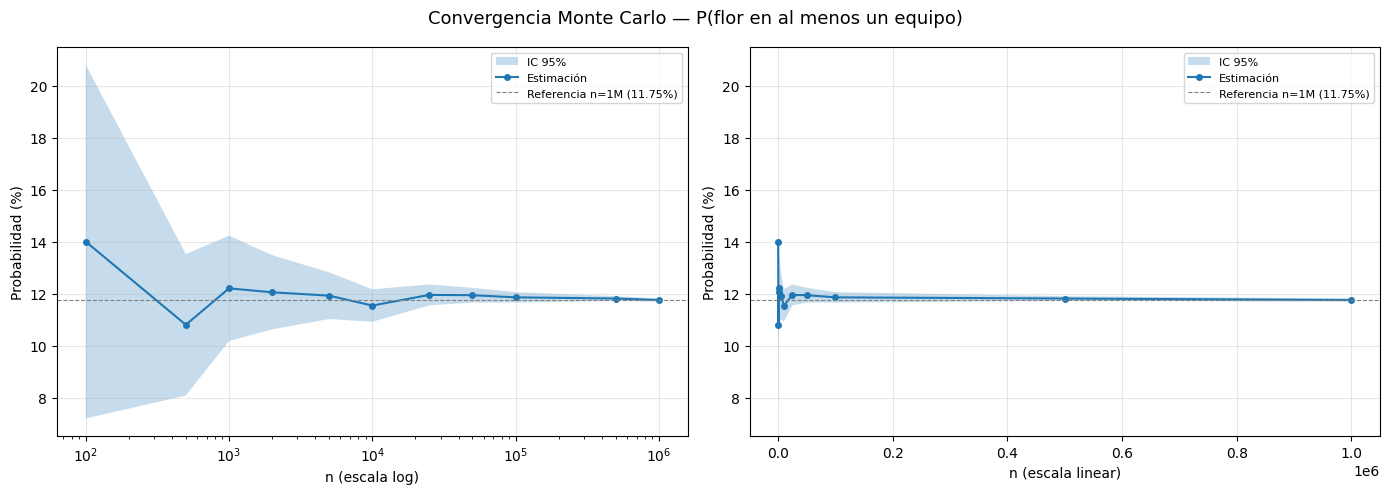

Guardado en plots/convergencia.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Convergencia Monte Carlo — P(flor en al menos un equipo)', fontsize=13)

for ax, xscale in zip(axes, ['log', 'linear']):
    ax.fill_between(NS, lows, highs, alpha=0.25, label='IC 95%')
    ax.plot(NS, ps, marker='o', markersize=4, label='Estimación')
    ax.axhline(ps[-1], color='gray', linestyle='--', linewidth=0.8, label=f'Referencia n=1M ({ps[-1]:.2f}%)')
    ax.set_xscale(xscale)
    ax.set_xlabel('n (escala ' + xscale + ')')
    ax.set_ylabel('Probabilidad (%)')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/convergencia.png', dpi=150)
plt.show()
print('Guardado en plots/convergencia.png')

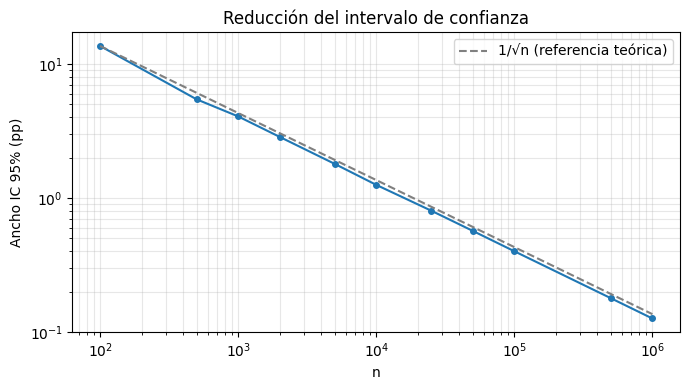

Guardado en plots/ic_vs_n.png


In [3]:
# Ancho del IC vs n
widths = [h - l for h, l in zip(highs, lows)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(NS, widths, marker='o', markersize=4)
ax.set_xlabel('n')
ax.set_ylabel('Ancho IC 95% (pp)')
ax.set_title('Reducción del intervalo de confianza')
ax.grid(True, which='both', alpha=0.3)

# Referencia teórica 1/sqrt(n)
ref = widths[0] * np.sqrt(NS[0]) / np.sqrt(NS)
ax.loglog(NS, ref, linestyle='--', color='gray', label='1/√n (referencia teórica)')
ax.legend()

plt.tight_layout()
plt.savefig('plots/ic_vs_n.png', dpi=150)
plt.show()
print('Guardado en plots/ic_vs_n.png')